# An introduction to the SMILES ARbitrary Target Specification (SMARTS)

Install the necessary Python packages

In [1]:
%pip install rdkit mols2grid

  Using cached mols2grid-2.2.0-py3-none-any.whl.metadata (15 kB)
  Using cached anywidget-0.11.0-py3-none-any.whl.metadata (8.9 kB)
  Using cached ipywidgets-8.1.9-py3-none-any.whl.metadata (2.4 kB)
  Using cached psygnal-0.15.1-cp314-cp314-macosx_11_0_arm64.whl.metadata (6.1 kB)
  Using cached widgetsnbextension-4.0.16-py3-none-any.whl.metadata (1.6 kB)
  Using cached jupyterlab_widgets-3.0.17-py3-none-any.whl.metadata (20 kB)
Using cached mols2grid-2.2.0-py3-none-any.whl (83 kB)
Using cached anywidget-0.11.0-py3-none-any.whl (317 kB)
Using cached ipywidgets-8.1.9-py3-none-any.whl (140 kB)
Using cached jupyterlab_widgets-3.0.17-py3-none-any.whl (217 kB)
Using cached widgetsnbextension-4.0.16-py3-none-any.whl (2.2 MB)
Using cached psygnal-0.15.1-cp314-cp314-macosx_11_0_arm64.whl (575 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [mols2grid]

[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restar

Load the necessary Python packages

In [2]:
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import rdDepictor
from rdkit import Chem

IPythonConsole.ipython_useSVG = True
IPythonConsole.molSize = 300, 300
rdDepictor.SetPreferCoordGen(True)

## Introduction

The **SM**ILES **AR**bitrary **T**arget **S**pecification (SMARTS) is a language **for pattern matching in molecules**.  SMARTS provides concise means of matching specific substructures in molecules.  Like SMILES, SMARTS was developed and refined by [Dave Weininger](https://en.wikipedia.org/wiki/David_Weininger) and colleagues at Daylight Chemical Information Systems.  

The canonical reference for SMARTS is the [Daylight Theory Manual](https://www.daylight.com/dayhtml/doc/theory/), I've borrowed liberally from that here. The [Daylight SMARTS Tutorial](https://www.daylight.com/dayhtml_tutorials/languages/smarts/index.html) is another essential reference. 

SMARTS share a lot of the same syntax as SMILES but there are a number of critical differences. At a simple level, any SMILES is also a valid SMARTS. However, a query with that SMARTS may not give you the answer you want. This can best be explained via an example.

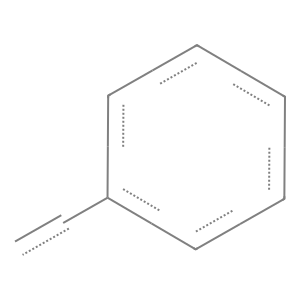

In [3]:
query_mol = Chem.MolFromSmarts("c1ccccc1C")
query_mol

Now, let's create a molecule that we'll match. As a first example, we'll use ethylbenzene. Since this is a molecule, not a query for searching, we'll use Chem.MolFromSmiles.

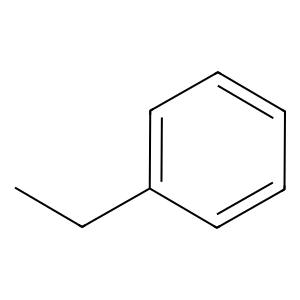

In [6]:
ethyl_benzene = Chem.MolFromSmiles("c1ccccc1CC")
ethyl_benzene

We can now see if our query matches ethyl benzene by using the HasSubstructMatch method of the ethyl_benzene molecule object.

In [7]:
ethyl_benzene.HasSubstructMatch(query_mol)

True

The value True above indicates that the ethyl_benzene molecule object does indeed contain the substructure specified by query_mol. We can use the function GetSubstructMatch to identify the specific atoms matching a pattern. The code below shows that the pattern specified by query_mol matches atoms 0,1,2,3,4,5 and 6.

In [8]:
ethyl_benzene.GetSubstructMatch(query_mol)

(0, 1, 2, 3, 4, 5, 6)

One interesting side effect of the call to **GetSubstructMatch** above is that the depiction shows the selected atoms as highlighted.

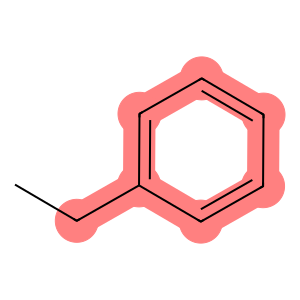

In [9]:
ethyl_benzene

### Properties of Atoms

So far so good, now let's create another molecule and look at how our pattern matches. This time we'll use biphenyl. 

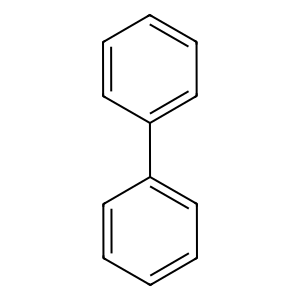

In [10]:
biphenyl = Chem.MolFromSmiles("c1ccccc1c2ccccc2")
biphenyl

In [11]:
biphenyl.HasSubstructMatch(query_mol)

False

Why didn't the query match? It's because the query SMARTS c1ccccc1C specified a phenyl ring connected to an aliphatic carbon. In biphenyl the corresponding carbon atom is aromatic. In SMARTS, "C" only matches aliphatic carbon atoms and "c" only matches aromatic carbon atoms. If we wish to match any carbon we can use "[#6]" to specify the atom.

In [12]:
new_query_mol = Chem.MolFromSmarts("c1ccccc1[#6]")
biphenyl.HasSubstructMatch(new_query_mol)

True

A similar approach can be applied with other atom types, we can specify any nitrogen atom as [#7] or any oxygen atom as [#8].

SMARTS can also be used to query for atoms with a particular charge. For instance, the SMARTS [-1] can be used to identify molecules with a charge of -1. Note that searching with a SMARTS this way will only identify molecules that were input with a charge of -1. SMARTS searching does not attempt to determine a molecule's ionization state. In the example below, we match the SMARTS [-1] against neutral and charged versions of acetic acid.

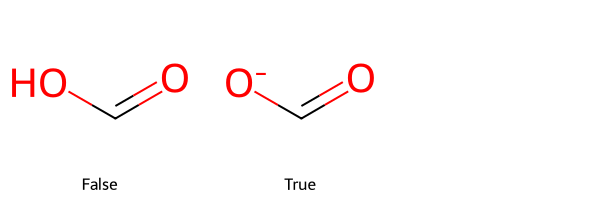

In [13]:
# An list of SMILES with acetic acid and acetate anion
smiles_list = ["C(=O)O","C(=O)[O-]"]
# Convert SMILES to RDKit molecules
mol_list = [Chem.MolFromSmiles(x) for x in smiles_list]
# Create a query molecule from SMARTS
anion_query = Chem.MolFromSmarts("[-1]")
# Match the query to the molecules, convert the output to string so that MolsToGrid can display as a legend
match_list = [str(x.HasSubstructMatch(anion_query)) for x in mol_list]
# Draw the structures
Chem.Draw.MolsToGridImage(mol_list,legends=match_list)

### Queries With Atom Lists

In many cases, we want to be able to create a query that will match multiple atom types.  For instance, we may want to create a query that will match both benzene and pyridine.  We can do this by specifying a comma-separated list of atom types in square brackets.  We can specify a query that will match benzene and pyridine with the SMARTS **c1cccc[c,n]1**.

In [14]:
smiles_list = ["c1ccccc1","c1ccccn1"]
mol_list = [Chem.MolFromSmiles(x) for x in smiles_list]
query_mol = Chem.MolFromSmarts("c1cccc[c,n]1")
[x.HasSubstructMatch(query_mol) for x in mol_list]

[True, True]

Note that we could also rewrite the query we used above to match aromatic and aliphatic carbon atoms as **c1cccc[c,C]1**.

In [24]:
smiles_list = ["c1ccccc1C","c1ccccc1c2ccccc2" ]
mol_list = [Chem.MolFromSmiles(x) for x in smiles_list]
query_mol = Chem.MolFromSmarts("c1cccc[c,C]1")
result = [x.HasSubstructMatch(query_mol) for x in mol_list]
result

[True, True]

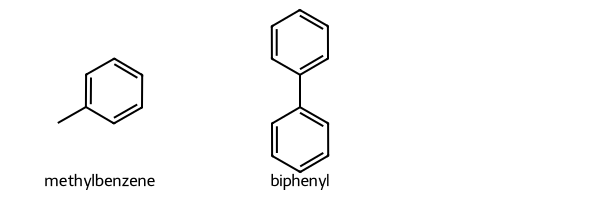

In [31]:
Chem.Draw.MolsToGridImage(mol_list, legends=["methylbenzene", "biphenyl"])

In [37]:
matches = [mol.GetSubstructMatch(query_mol) for mol in mol_list]
matches

[(0, 1, 2, 3, 4, 5), (0, 1, 2, 3, 4, 5)]

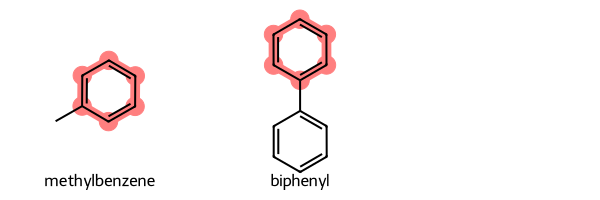

In [38]:
Chem.Draw.MolsToGridImage(
    mol_list,
    legends=["methylbenzene", "biphenyl"],
    highlightAtomLists=matches
)

Atom lists can also include atom specifiers such as [#8]. We can construct a query that matches any nitrogen or oxygen attached to an aliphatic carbon as C[#7,#8].

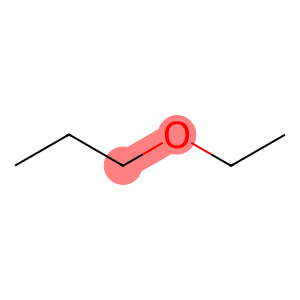

In [40]:
mol = Chem.MolFromSmiles("CCCOCC")
query_mol = Chem.MolFromSmarts("C[#7,#8]")
mol.GetSubstructMatch(query_mol)
mol

### SMARTS Specifying the Number of Attachments to an Atom

There are two ways of writing queries that specify the number of attachments to an atom (does not count H).  Valence, which is specified with "v" and degree which is specified with "D".  I'm the first to admit that I still confuse these and usually need to write a couple of examples to remember how this works.  In order to do test the two types of queries, let's define a few molecules. 

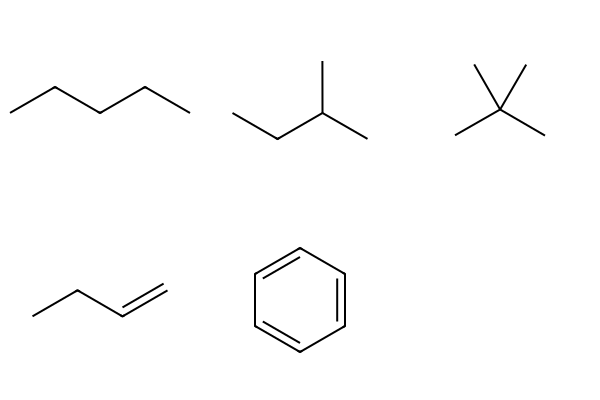

In [41]:
smiles_list = ["CCCCC","CC(C)CC","CC(C)(C)C","C=CCC","c1ccccc1"]
mol_list = [Chem.MolFromSmiles(x) for x in smiles_list]
Chem.Draw.MolsToGridImage(mol_list)

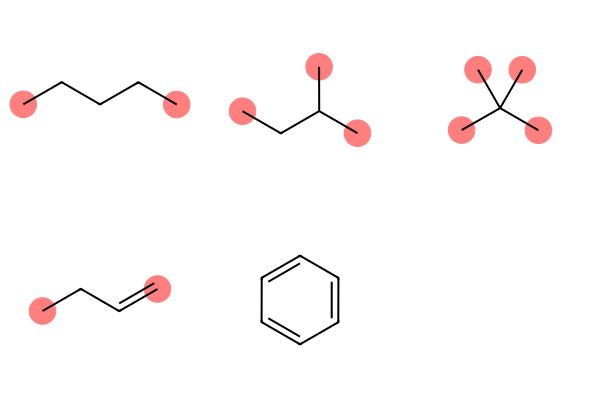

In [65]:
query_smarts = "[D1]"
query_mol = Chem.MolFromSmarts(query_smarts)
match_list = []
for mol in mol_list:
    matches = mol.GetSubstructMatches(query_mol)   # усі збіги
    atoms = [a for m in matches for a in m]         # об'єднати в один список
    match_list.append(atoms)

Chem.Draw.MolsToGridImage(mol_list, highlightAtomLists=match_list)

## D and v in SMARTS

Two ways to specify the number of attachments to an atom.

### D — degree
Counts the number of neighboring **heavy atoms** (explicit connections, hydrogens not counted). Bond order doesn't matter — a double bond still counts as **1** connection.

- `[D1]` = atom with one neighbor (e.g. a terminal CH₃)
- `[D2]` = atom with two neighbors (e.g. a middle CH₂)
- `[D3]`, `[D4]` = branch points

### v — valence
Counts the **sum of bond orders** of all bonds on the atom, **including bonds to hydrogen**.

Bond order = bond multiplicity:
- single bond = 1
- double bond = 2
- triple bond = 3

`v` = add up the orders of every bond leaving the atom.

### Bond order examples (carbon is always tetravalent → v4)
- **CH₄**: four single C–H bonds → 1+1+1+1 = **v4**
- **=CH₂** (ethylene): one double bond (2) + two C–H (1+1) → **v4**
- **≡CH** (acetylene): one triple bond (3) + one C–H (1) → **v4**

### Key difference
The distinction is clearest on a double bond: a terminal `=CH₂` has **D1** (one neighbor) but **v2** from that double bond.

| | Counts | Double bond contributes |
|---|---|---|
| **D** | neighboring heavy atoms | 1 |
| **v** | sum of all bond orders (incl. H) | 2 |

Because carbon is almost always v4, `D` is usually more useful for telling atoms apart — it reflects actual branching (how many neighbors), while `v` tends to be constant.

### Tip
`GetSubstructMatch` returns only the **first** match (one atom highlighted). Use `GetSubstructMatches` to get **all** matching atoms.

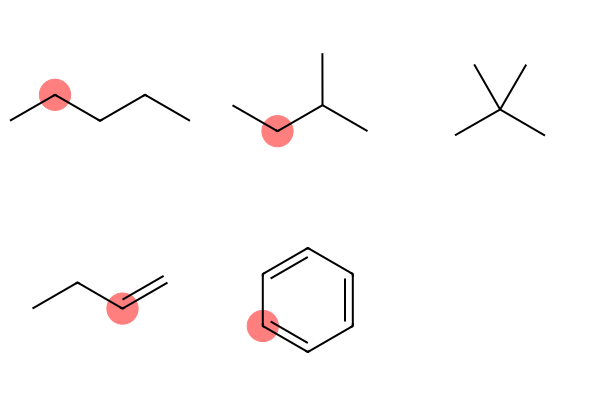

In [66]:
query_smarts = "[D2]"
query_mol = Chem.MolFromSmarts(query_smarts)
match_list = []
for mol in mol_list:
    match_list.append(mol.GetSubstructMatch(query_mol))
Chem.Draw.MolsToGridImage(mol_list,highlightAtomLists=match_list)

In [67]:
mol_list[0].GetSubstructMatches(query_mol)

((1,), (2,), (3,))

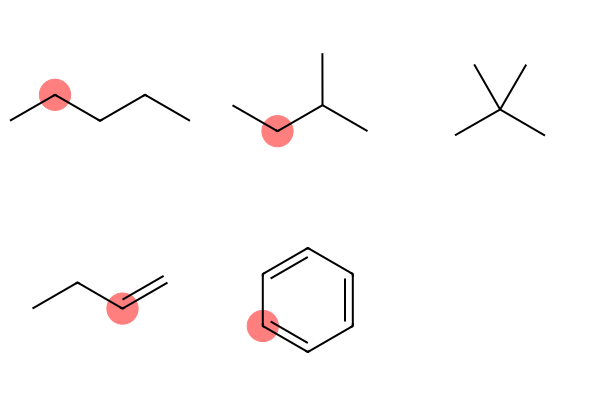

In [68]:
Chem.Draw.MolsToGridImage(mol_list,highlightAtomLists=match_list)

In this section, we'll use the amazing mols2grid component to interactively practice our SMARTS searching skills.  mols2grid provides the ability to create a paginated table of chemical structures.  We can also use this table to select structures and programmatically grab the selected structures.  In addition, mols2grid provides the ability to interactively search the table using SMARTS. A SMARTS search in mols2grid does two things.
- Filters the table so that only molecules matching the SMARTS are shown
- Highlights the atoms matching the SMARTS

In order to search the mols2grid table using SMARTS, we need to do the following: 
- Click on the magnifying glass in the lower right corner
- Select SMARTS

<img src="https://raw.githubusercontent.com/PatWalters/practical_cheminformatics_tutorials/main/images/smarts_tutorial_using_mols2grid.png" />

In the code block below, we create a grid with the five molecules in mol_list.  Try this out with a few queries.
- aliphatic carbon - C
- aromatic carbon - c
- vinyl group C=C
- trisubstituted carbon [#6D3]
- carbon with three attached bonds [#6X3]

In [70]:
import mols2grid
mols2grid.display(mol_list,substruct_highlight=True)

### Additional Atom Primitives
Use the grid below to try out of some other SMARTS atom primitives.  The table below was taken from [The RDKit Book](https://www.rdkit.org/docs/RDKit_Book.html)
<img src="https://raw.githubusercontent.com/PatWalters/practical_cheminformatics_tutorials/main/images/smarts_atom_primitives.png" width="800"/>

See if you can find: 
- All the molecules with a six membered ring
- All the molecules with a four membered ring
- All the carboxylic acids
- All the esters
- All the primary amines
- All the sp2 hybridized carbons
- All the atoms contained in 2 rings
- Ureas

## SMARTS Query Solutions

| Query | SMARTS | What it matches | Key primitives used |
|---|---|---|---|
| Six-membered ring | `[r6]` | Any atom that is part of a ring of size 6 (e.g. benzene, piperidine, cyclohexane) | `r6` = smallest ring containing this atom has 6 members |
| Four-membered ring | `[r4]` | Any atom in a 4-membered ring (e.g. β-lactams, cyclobutane) | `r4` = atom in a ring of size 4 |
| Carboxylic acids | `[CX3](=O)[OX2H1]` | The –COOH group: a trigonal carbon double-bonded to O and single-bonded to an –OH | `CX3` = C with 3 connections; `=O` carbonyl; `OX2H1` = oxygen with 2 bonds and 1 H |
| Esters | `[CX3](=O)[OX2H0][#6]` | The –C(=O)–O–C ester linkage; the ester oxygen carries no H and connects to another carbon | `OX2H0` = oxygen, 2 bonds, no H (distinguishes from acid); `[#6]` = any carbon |
| Primary amines | `[NX3;H2;!$(NC=O)]` | An sp³ nitrogen bearing exactly 2 hydrogens, excluding amides | `NX3` = 3-connected N; `H2` = 2 hydrogens; `!$(NC=O)` = NOT an amide |
| sp² carbons | `[#6X3]` | Any trigonal (sp²) carbon: alkene, carbonyl, or aromatic carbon | `X3` = 3 total connections (H counted); a double bond counts as one connection |
| Atoms in 2 rings | `[R2]` | An atom that is a member of exactly 2 SSSR rings (e.g. a fusion/bridgehead atom) | `R2` = ring-membership count of 2 (note capital R vs lowercase r) |
| Ureas | `[NX3][CX3](=[OX1])[NX3]` | The N–C(=O)–N urea motif | Two 3-connected nitrogens flanking a carbonyl carbon |

### Primitive cheat sheet

| Symbol | Meaning | Counts H? |
|---|---|---|
| `X<n>` | total number of connections (bonds to any atom) | **yes** |
| `D<n>` | degree — number of heavy-atom neighbors | no |
| `H<n>` | number of attached hydrogens | — |
| `v<n>` | valence — sum of bond orders | yes |
| `r<n>` | atom is in a ring **of size** n | — |
| `R<n>` | atom is a member of **n rings** | — |
| `#6` | atomic number 6 (carbon), any hybridization/aromaticity | — |
| `!` | logical NOT | — |
| `$(...)` | recursive SMARTS — match if the atom sits in this environment | — |
| `;` | logical AND (low precedence) | — |

### Notes & gotchas

- **`r` vs `R`**: lowercase `r6` means "in a ring of size 6"; uppercase `R2` means "belongs to 2 rings." Easy to mix up.
- **`X` counts hydrogens, `D` does not.** For an alkene carbon `H₂C=`, `X3` matches (2 H + 1 C) while `D1` matches (1 heavy neighbor). A double bond counts as **one** connection for both `X` and `D`.
- **Acid vs ester** hinges on the oxygen: `OX2H1` (has an H) → acid; `OX2H0[#6]` (no H, bonded to carbon) → ester.
- **Recursive SMARTS `$(...)`** lets you describe an atom by its surroundings without those surrounding atoms being part of the match — used above to exclude amide nitrogens from primary amines.
- **sp² by connectivity**: a carbon with 3 connections is trigonal/sp², which is why `[#6X3]` captures alkene, carbonyl, and aromatic carbons alike.

In [73]:
import ssl, certifi, urllib.request
import pandas as pd
import mols2grid

url = "https://raw.githubusercontent.com/PatWalters/practical_cheminformatics_tutorials/main/data/smarts_test.smi"

ctx = ssl.create_default_context(cafile=certifi.where())
with urllib.request.urlopen(url, context=ctx) as resp:
    df = pd.read_csv(resp, sep=" ", names=["SMILES", "Name"])

mols2grid.display(df, subset=["img", "Name"])